# Homogeneous Poisson Process — From Scratch and With NumPyro

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/hpp_from_scratch_and_numpyro.ipynb)

A **homogeneous Poisson process** (HPP) with intensity $\lambda > 0$ on $[0, T]$ has

* count $N \sim \mathrm{Poisson}(\lambda T)$,
* conditional event times i.i.d. uniform on $[0, T]$ given the count,
* compensator $\Lambda(t) = \lambda t$,
* log-likelihood $\log L = n \log \lambda - \lambda T$.

This notebook shows both faces of `xtremax` for the HPP:

1. **From scratch** — work directly with the pure-JAX primitives (`hpp_log_prob`, `hpp_sample`, `hpp_cumulative_intensity`). No class state, no framework.
2. **With NumPyro** — wrap the same process as a `numpyro.distributions.Distribution` and run Bayesian inference via NUTS.

## Setup

In [1]:
%pip install -q xtremax matplotlib  # uncomment on Colab
import math

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import MCMC, NUTS

from xtremax.point_processes.distributions import (
    HomogeneousPoissonProcess as HppDist,
)
from xtremax.point_processes.primitives import (
    hpp_cumulative_intensity,
    hpp_log_prob,
    hpp_sample,
)


plt.rcParams["figure.figsize"] = (8.0, 3.5)

/home/azureuser/localfiles/xtremax/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


/home/azureuser/localfiles/xtremax/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. From scratch — the primitives layer

`xtremax.point_processes.primitives` ships the HPP as a set of pure JAX functions. Every call takes arrays and returns arrays — no classes, no framework. That's all we need to sample, evaluate the likelihood, and visualise the process.

### Sampling

In [2]:
true_rate = 2.0
T = 10.0

key = random.PRNGKey(0)
times, mask, n_events = hpp_sample(key, rate=true_rate, T=T, max_events=64)
print(f"Drew n_events = {int(n_events)} (λT = {true_rate * T:.1f})")
print(f"First five event times: {times[mask][:5]}")

Drew n_events = 13 (λT = 20.0)
First five event times: [0.0729382  0.2089119  0.950073   0.96612096 1.1928833 ]


The sampler returns `(times, mask, n_events)`. Variable-length sequences can't be ragged under `jax.jit`, so events live in a **padded** buffer of size `max_events` with a boolean `mask` marking real events. This keeps the primitive `jit` and `vmap` compatible — useful for running many realisations in parallel (see below).

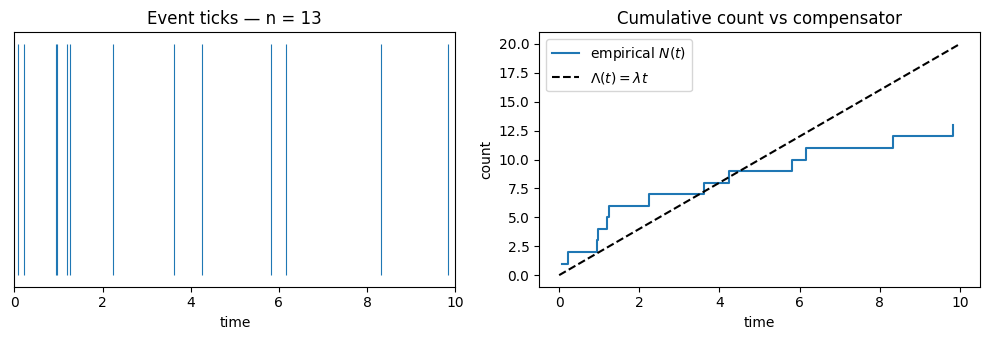

In [3]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3.5))

real_times = np.asarray(times[mask])
ax0.vlines(real_times, 0, 1, color="C0", linewidth=0.8)
ax0.set_xlim(0, T)
ax0.set_yticks([])
ax0.set_xlabel("time")
ax0.set_title(f"Event ticks — n = {len(real_times)}")

counts = np.arange(1, len(real_times) + 1)
ax1.step(real_times, counts, where="post", color="C0", label="empirical $N(t)$")
grid = np.linspace(0, T, 100)
ax1.plot(
    grid,
    np.asarray(hpp_cumulative_intensity(jnp.asarray(grid), true_rate)),
    "k--",
    label=r"$\Lambda(t) = \lambda t$",
)
ax1.legend()
ax1.set_xlabel("time")
ax1.set_ylabel("count")
ax1.set_title("Cumulative count vs compensator")

plt.tight_layout()
plt.show()

### Evaluating the log-likelihood

`hpp_log_prob(n_events, rate, T)` returns $n \log \lambda - \lambda T$. Because it's a pure JAX function it composes with `jax.vmap` — scan a grid of candidate rates against the observed count in one call and read off the maximum-likelihood estimate.

Grid-search MLE    : λ̂ = 1.298
Closed-form MLE    : λ̂ = 1.300


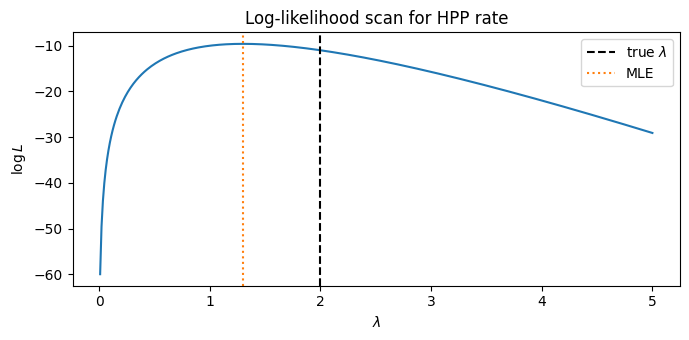

In [4]:
n_obs = int(n_events)

rate_grid = jnp.linspace(0.01, 5.0, 400)
log_lik_grid = jax.vmap(lambda r: hpp_log_prob(jnp.asarray(n_obs), r, T))(rate_grid)

mle_rate = float(rate_grid[jnp.argmax(log_lik_grid)])
print(f"Grid-search MLE    : λ̂ = {mle_rate:.3f}")
print(f"Closed-form MLE    : λ̂ = {n_obs / T:.3f}")  # n / T for any HPP

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(np.asarray(rate_grid), np.asarray(log_lik_grid), color="C0")
ax.axvline(true_rate, color="k", linestyle="--", label=r"true $\lambda$")
ax.axvline(mle_rate, color="C1", linestyle=":", label="MLE")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$\log L$")
ax.set_title("Log-likelihood scan for HPP rate")
ax.legend()
plt.tight_layout()
plt.show()

### Many realisations in parallel via `vmap`

Verify empirically that $N \sim \mathrm{Poisson}(\lambda T)$ by drawing a few thousand sequences and comparing the count histogram with the exact PMF.

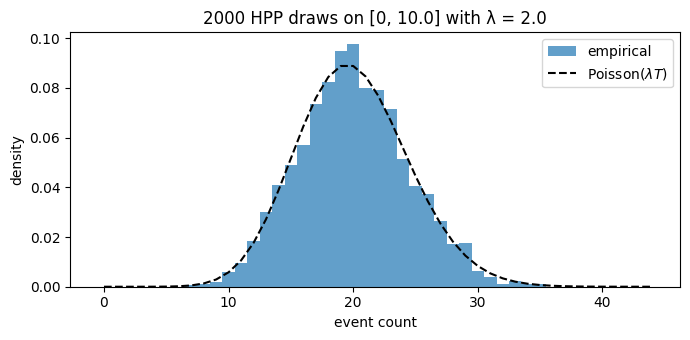

In [5]:
keys = random.split(random.PRNGKey(42), 2000)
counts = jax.vmap(lambda k: hpp_sample(k, true_rate, T, max_events=64)[2])(keys)

xs = np.arange(0, 45)
log_factorial = np.array([math.lgamma(int(x) + 1) for x in xs])
poisson_pmf = np.exp(xs * np.log(true_rate * T) - (true_rate * T) - log_factorial)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(
    np.asarray(counts),
    bins=np.arange(0, 45) - 0.5,
    density=True,
    alpha=0.7,
    color="C0",
    label="empirical",
)
ax.plot(xs, poisson_pmf, "k--", label=r"Poisson$(\lambda T)$")
ax.legend()
ax.set_xlabel("event count")
ax.set_ylabel("density")
ax.set_title(f"2000 HPP draws on [0, {T}] with λ = {true_rate}")
plt.tight_layout()
plt.show()

## 2. With NumPyro — Bayesian inference

To put a prior on $\lambda$ and get a full posterior we wrap the HPP as a `numpyro.distributions.Distribution`. The wrapper's `.log_prob` delegates to the same primitive we just used — nothing magic happens in the shim — but NumPyro can now compose it as a likelihood site inside a model with priors and run NUTS.

### Sample / log_prob round-trip

The distribution returns a `(times, mask)` PyTree from `.sample`, and `.log_prob` accepts exactly that PyTree — so `log_prob(sample(key))` is a valid round-trip.

In [6]:
hpp_d = HppDist(rate=true_rate, observation_window=T, max_events=128)
value = hpp_d.sample(random.PRNGKey(1))
print("sample() returns", type(value).__name__, "of length", len(value))
print("round-trip log_prob:", float(hpp_d.log_prob(value)))

sample() returns tuple of length 2
round-trip log_prob: -2.6713199615478516


### NUTS for the rate parameter

Place a weakly informative log-normal prior on $\lambda$ and condition on the count we observed in section 1.

In [7]:
observed_n = jnp.asarray(n_obs)


def model():
    rate = numpyro.sample("rate", dist.LogNormal(0.0, 1.0))
    hpp = HppDist(rate, T, max_events=128)
    # The HPP likelihood only depends on the count; pass zeros as the
    # unused ``times`` component.
    numpyro.factor("lik", hpp.log_prob((jnp.zeros(128), observed_n)))


mcmc = MCMC(NUTS(model), num_warmup=500, num_samples=1000, progress_bar=False)
mcmc.run(random.PRNGKey(0))
posterior = np.asarray(mcmc.get_samples()["rate"])

print(f"Posterior mean : {posterior.mean():.3f}")
print(
    f"Posterior 95%  : [{np.quantile(posterior, 0.025):.3f}, "
    f"{np.quantile(posterior, 0.975):.3f}]"
)
print(f"MLE            : {n_obs / T:.3f}")
print(f"Ground truth   : {true_rate}")

Posterior mean : 1.276
Posterior 95%  : [0.719, 2.016]
MLE            : 1.300
Ground truth   : 2.0


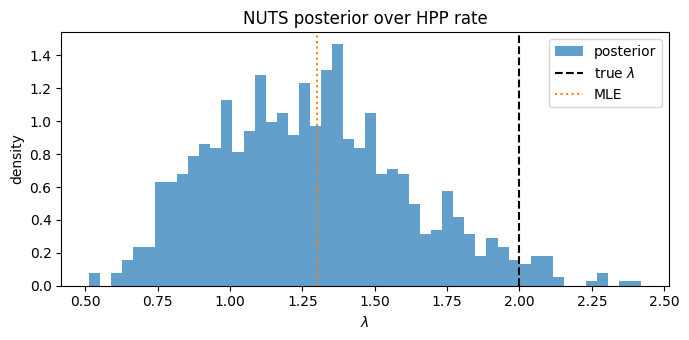

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(posterior, bins=50, density=True, alpha=0.7, color="C0", label="posterior")
ax.axvline(true_rate, color="k", linestyle="--", label=r"true $\lambda$")
ax.axvline(n_obs / T, color="C1", linestyle=":", label="MLE")
ax.legend()
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("density")
ax.set_title("NUTS posterior over HPP rate")
plt.tight_layout()
plt.show()

### Posterior predictive check

Draw rates from the posterior, simulate new event sequences with the same primitive as before, and check that the predicted count distribution covers the observation.

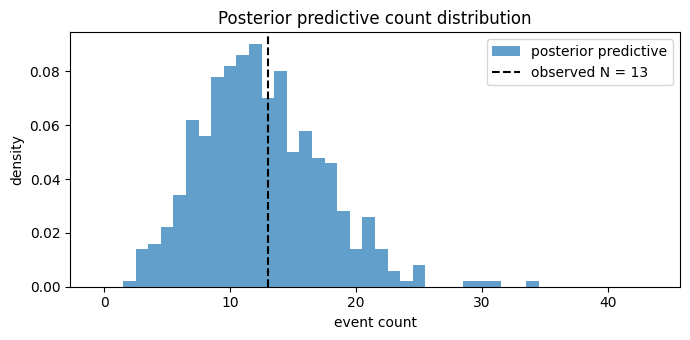

In [9]:
rng = np.random.default_rng(2026)
post_rates = jnp.asarray(rng.choice(posterior, size=500))
keys_pp = random.split(random.PRNGKey(2), 500)


def predictive_count(key, rate):
    _, _, n = hpp_sample(key, rate, T, max_events=128)
    return n


pp_counts = np.asarray(jax.vmap(predictive_count)(keys_pp, post_rates))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(
    pp_counts,
    bins=np.arange(0, 45) - 0.5,
    density=True,
    alpha=0.7,
    color="C0",
    label="posterior predictive",
)
ax.axvline(n_obs, color="k", linestyle="--", label=f"observed N = {n_obs}")
ax.legend()
ax.set_xlabel("event count")
ax.set_ylabel("density")
ax.set_title("Posterior predictive count distribution")
plt.tight_layout()
plt.show()

## Takeaways

* The **primitives layer** gives you the math as plain JAX functions — `hpp_log_prob`, `hpp_sample`, `hpp_cumulative_intensity`. Everything is `jit` / `vmap` clean so you can scan log-likelihoods or batch thousands of draws with no ceremony.
* The **NumPyro wrapper** is a thin shim that delegates to the same primitives; it exists so the HPP can appear as a likelihood site inside a `numpyro.sample` / MCMC / SVI workflow.
* The `(times, mask)` padded PyTree is the canonical event-sequence representation, and the same representation round-trips between `.sample` and `.log_prob` on the distribution.